In [39]:
import pandas as pd
df = pd.read_excel("OLA_DataSet.xlsx")
df


,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,Canceled_Rides_by_Customer,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Vehicle Images
0,2024-07-26 14:00:00,14:00:00,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,NaN,NaN,NaN,Personal & Car related issue,NaN,NaN,444,NaN,0,NaN,NaN,https://cdn-icons-png.flaticon.com/128/14183/1...
1,2024-07-25 22:20:00,22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,NaN,NaN,No,NaN,158,Cash,13,4.1,4.0,https://cdn-icons-png.flaticon.com/128/9983/99...
2,2024-07-30 19:59:00,19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,NaN,NaN,No,NaN,386,UPI,40,4.2,4.8,https://cdn-icons-png.flaticon.com/128/9983/99...
3,2024-07-22 03:15:00,03:15:00,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,NaN,NaN,Driver is not moving towards pickup location,NaN,NaN,NaN,384,NaN,0,NaN,NaN,https://cdn-icons-png.flaticon.com/128/6839/68...
4,2024-07-02 09:02:00,09:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,NaN,NaN,No,NaN,822,Credit Card,45,4.0,3.0,https://cdn-icons-png.flaticon.com/128/3202/32...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103019,2024-07-31 09:06:00,09:06:00,CNR9488489435,Success,CID371654,Prime Plus,Richmond Town,Varthur,245.0,35.0,NaN,NaN,No,NaN,111,Cash,41,3.6,3.8,https://cdn-icons-png.flaticon.com/128/11409/1...
103020,2024-07-31 15:12:00,15:12:00,CNR3151743100,Success,CID334158,Auto,Vijayanagar,Richmond Town,84.0,145.0,NaN,NaN,No,NaN,1097,UPI,17,4.3,3.3,https://cdn-icons-png.flaticon.com/128/16526/1...
103021,2024-07-31 13:59:00,13:59:00,CNR1286151233,Success,CID113188,Prime SUV,Bannerghatta Road,JP Nagar,35.0,75.0,NaN,NaN,No,NaN,2201,Cash,37,3.6,3.2,https://cdn-icons-png.flaticon.com/128/9983/99...
103022,2024-07-31 14:56:00,14:56:00,CNR2027162035,Success,CID118301,eBike,Indiranagar,Magadi Road,210.0,140.0,NaN,NaN,No,NaN,267,UPI,47,3.4,3.1,https://cdn-icons-png.flaticon.com/128/6839/68...


In [3]:
df.shape

(103024, 20)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103024 entries, 0 to 103023
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Date                        103024 non-null  datetime64[us]
 1   Time                        103024 non-null  object        
 2   Booking_ID                  103024 non-null  str           
 3   Booking_Status              103024 non-null  str           
 4   Customer_ID                 103024 non-null  str           
 5   Vehicle_Type                103024 non-null  str           
 6   Pickup_Location             103024 non-null  str           
 7   Drop_Location               103024 non-null  str           
 8   V_TAT                       63967 non-null   float64       
 9   C_TAT                       63967 non-null   float64       
 10  Canceled_Rides_by_Customer  10499 non-null   str           
 11  Canceled_Rides_by_Driver    18434 non-null   str  

In [5]:
df.columns=(df.columns
           .str.strip()
           .str.lower()
           .str.replace(" ","_"))

In [6]:
df.columns

Index(['date', 'time', 'booking_id', 'booking_status', 'customer_id',
       'vehicle_type', 'pickup_location', 'drop_location', 'v_tat', 'c_tat',
       'canceled_rides_by_customer', 'canceled_rides_by_driver',
       'incomplete_rides', 'incomplete_rides_reason', 'booking_value',
       'payment_method', 'ride_distance', 'driver_ratings', 'customer_rating',
       'vehicle_images'],
      dtype='str')

In [7]:
df['date']=pd.to_datetime(df['date'])

In [8]:
df['day'] = pd.to_datetime(df['date']).dt.day_name()
df['year'] = pd.to_datetime(df['date']).dt.year
df['month']=pd.to_datetime(df['date']).dt.month

In [9]:
df.isna().sum().sort_values(ascending=False)

incomplete_rides_reason       99098
canceled_rides_by_customer    92525
canceled_rides_by_driver      84590
v_tat                         39057
driver_ratings                39057
c_tat                         39057
incomplete_rides              39057
customer_rating               39057
payment_method                39057
customer_id                       0
vehicle_type                      0
booking_id                        0
time                              0
date                              0
booking_status                    0
pickup_location                   0
drop_location                     0
booking_value                     0
ride_distance                     0
vehicle_images                    0
day                               0
year                              0
month                             0
dtype: int64

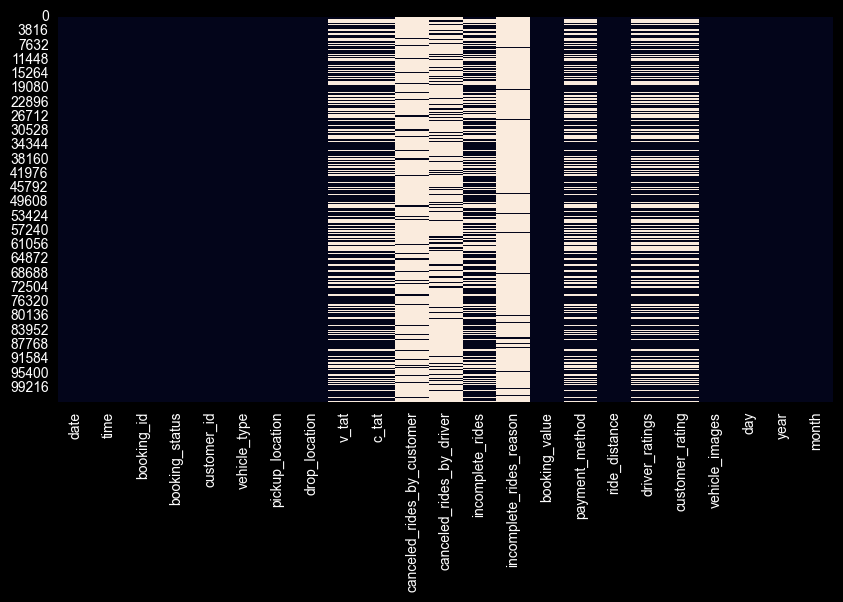

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.heatmap(df.isna(), cbar=False)
plt.title="missing value heatmap"
plt.show()

In [11]:
df.isnull().sum()/len(df)*100.

date                           0.000000
time                           0.000000
booking_id                     0.000000
booking_status                 0.000000
customer_id                    0.000000
vehicle_type                   0.000000
pickup_location                0.000000
drop_location                  0.000000
v_tat                         37.910584
c_tat                         37.910584
canceled_rides_by_customer    89.809171
canceled_rides_by_driver      82.107082
incomplete_rides              37.910584
incomplete_rides_reason       96.189237
booking_value                  0.000000
payment_method                37.910584
ride_distance                  0.000000
driver_ratings                37.910584
customer_rating               37.910584
vehicle_images                 0.000000
day                            0.000000
year                           0.000000
month                          0.000000
dtype: float64

In [12]:
success_df = df[df['booking_status']=='Success']
cancel_df = df[df['booking_status']!='Success']

In [13]:
import numpy as np
df.replace('null', np.nan, inplace=True)

,date,time,booking_id,booking_status,customer_id,vehicle_type,pickup_location,drop_location,v_tat,c_tat,...,incomplete_rides_reason,booking_value,payment_method,ride_distance,driver_ratings,customer_rating,vehicle_images,day,year,month
0,2024-07-26 14:00:00,14:00:00,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,NaN,NaN,...,NaN,444,NaN,0,NaN,NaN,https://cdn-icons-png.flaticon.com/128/14183/1...,Friday,2024,7
1,2024-07-25 22:20:00,22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,...,NaN,158,Cash,13,4.1,4.0,https://cdn-icons-png.flaticon.com/128/9983/99...,Thursday,2024,7
2,2024-07-30 19:59:00,19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,...,NaN,386,UPI,40,4.2,4.8,https://cdn-icons-png.flaticon.com/128/9983/99...,Tuesday,2024,7
3,2024-07-22 03:15:00,03:15:00,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,NaN,NaN,...,NaN,384,NaN,0,NaN,NaN,https://cdn-icons-png.flaticon.com/128/6839/68...,Monday,2024,7
4,2024-07-02 09:02:00,09:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,...,NaN,822,Credit Card,45,4.0,3.0,https://cdn-icons-png.flaticon.com/128/3202/32...,Tuesday,2024,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103019,2024-07-31 09:06:00,09:06:00,CNR9488489435,Success,CID371654,Prime Plus,Richmond Town,Varthur,245.0,35.0,...,NaN,111,Cash,41,3.6,3.8,https://cdn-icons-png.flaticon.com/128/11409/1...,Wednesday,2024,7
103020,2024-07-31 15:12:00,15:12:00,CNR3151743100,Success,CID334158,Auto,Vijayanagar,Richmond Town,84.0,145.0,...,NaN,1097,UPI,17,4.3,3.3,https://cdn-icons-png.flaticon.com/128/16526/1...,Wednesday,2024,7
103021,2024-07-31 13:59:00,13:59:00,CNR1286151233,Success,CID113188,Prime SUV,Bannerghatta Road,JP Nagar,35.0,75.0,...,NaN,2201,Cash,37,3.6,3.2,https://cdn-icons-png.flaticon.com/128/9983/99...,Wednesday,2024,7
103022,2024-07-31 14:56:00,14:56:00,CNR2027162035,Success,CID118301,eBike,Indiranagar,Magadi Road,210.0,140.0,...,NaN,267,UPI,47,3.4,3.1,https://cdn-icons-png.flaticon.com/128/6839/68...,Wednesday,2024,7


In [14]:
df['driver_ratings']=pd.to_numeric(df['driver_ratings'], errors='coerce')
df['customer_rating']=pd.to_numeric(df['customer_rating'], errors='coerce')


df['driver_ratings'].fillna(df['driver_ratings'].mean(), inplace=True)
df['customer_rating'].fillna(df['customer_rating'].mean(), inplace=True)


0         3.998313
1         4.000000
2         4.800000
3         3.998313
4         3.000000
            ...   
103019    3.800000
103020    3.300000
103021    3.200000
103022    3.100000
103023    4.400000
Name: customer_rating, Length: 103024, dtype: float64

In [15]:
df['booking_value']=pd.to_numeric(df['booking_value'], errors='coerce')
df['ride_distance']=pd.to_numeric(df['ride_distance'], errors='coerce')

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103024 entries, 0 to 103023
Data columns (total 23 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   date                        103024 non-null  datetime64[us]
 1   time                        103024 non-null  object        
 2   booking_id                  103024 non-null  str           
 3   booking_status              103024 non-null  str           
 4   customer_id                 103024 non-null  str           
 5   vehicle_type                103024 non-null  str           
 6   pickup_location             103024 non-null  str           
 7   drop_location               103024 non-null  str           
 8   v_tat                       63967 non-null   float64       
 9   c_tat                       63967 non-null   float64       
 10  canceled_rides_by_customer  10499 non-null   str           
 11  canceled_rides_by_driver    18434 non-null   str  

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 103024 entries, 0 to 103023
Data columns (total 23 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   date                        103024 non-null  datetime64[us]
 1   time                        103024 non-null  object        
 2   booking_id                  103024 non-null  str           
 3   booking_status              103024 non-null  str           
 4   customer_id                 103024 non-null  str           
 5   vehicle_type                103024 non-null  str           
 6   pickup_location             103024 non-null  str           
 7   drop_location               103024 non-null  str           
 8   v_tat                       63967 non-null   float64       
 9   c_tat                       63967 non-null   float64       
 10  canceled_rides_by_customer  10499 non-null   str           
 11  canceled_rides_by_driver    18434 non-null   str  

In [19]:
df.info()
df.describe()
df.head()


,date,time,booking_id,booking_status,customer_id,vehicle_type,pickup_location,drop_location,v_tat,c_tat,...,incomplete_rides_reason,booking_value,payment_method,ride_distance,driver_ratings,customer_rating,vehicle_images,day,year,month
0,2024-07-26 14:00:00,14:00:00,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,NaN,NaN,...,NaN,444,NaN,0,NaN,NaN,https://cdn-icons-png.flaticon.com/128/14183/1...,Friday,2024,7
1,2024-07-25 22:20:00,22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,...,NaN,158,Cash,13,4.1,4.0,https://cdn-icons-png.flaticon.com/128/9983/99...,Thursday,2024,7
2,2024-07-30 19:59:00,19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,...,NaN,386,UPI,40,4.2,4.8,https://cdn-icons-png.flaticon.com/128/9983/99...,Tuesday,2024,7
3,2024-07-22 03:15:00,03:15:00,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,NaN,NaN,...,NaN,384,NaN,0,NaN,NaN,https://cdn-icons-png.flaticon.com/128/6839/68...,Monday,2024,7
4,2024-07-02 09:02:00,09:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,...,NaN,822,Credit Card,45,4.0,3.0,https://cdn-icons-png.flaticon.com/128/3202/32...,Tuesday,2024,7


connecting pgadmin

In [20]:
from sqlalchemy.engine import URL
from sqlalchemy import create_engine

url = URL.create(
    drivername="postgresql+psycopg2",
    username="postgres",
    password="123",
    host="localhost",
    port=5432,
    database="Ola"
)

engine = create_engine(url)

print("Connected successfully!")


Connected successfully!


import data to pgadmin

In [21]:
df.to_sql(
    name="ola_rides",
    con=engine,
    if_exists="replace",   # replace table if exists
    index=False
)


24

Total Rides

In [22]:
query = """
SELECT COUNT(*) AS total_rides
FROM ola_rides;
"""

result = pd.read_sql(query, engine)
print(result)


   total_rides
0       103024


Cancellation Rate

In [23]:
from sqlalchemy import text

with engine.connect() as conn:
    result = conn.execute(text("""
        SELECT
            COUNT(*) AS total_rides,
            SUM(CASE WHEN booking_status LIKE '%Canceled%' THEN 1 ELSE 0 END) AS canceled_rides,
            ROUND(
                100.0 * SUM(CASE WHEN booking_status LIKE '%Canceled%' THEN 1 ELSE 0 END) / COUNT(*),
                2
            ) AS cancellation_percentage
        FROM ola_rides;
    """))

    for row in result:
        print(row)


(103024, 28933, Decimal('28.08'))


Peak Booking hour

In [24]:
query = """
SELECT EXTRACT(HOUR FROM date) AS hour,
       COUNT(*) AS ride_count
FROM ola_rides
GROUP BY hour
ORDER BY ride_count DESC;
"""

pd.read_sql(query, engine)


,hour,ride_count
0,12.0,4408
1,15.0,4376
2,8.0,4374
3,17.0,4353
4,9.0,4347
5,21.0,4343
6,10.0,4334
7,1.0,4329
8,0.0,4318
9,2.0,4305


Average Rating by Vehicle Type

In [25]:
query = """
SELECT vehicle_type,
       AVG(driver_ratings) AS avg_driver_rating
FROM ola_rides
WHERE booking_status = 'Success'
GROUP BY vehicle_type
ORDER BY avg_driver_rating DESC;
"""

pd.read_sql(query, engine)


,vehicle_type,avg_driver_rating
0,eBike,4.006743
1,Prime SUV,4.005780
2,Auto,4.003938
3,Prime Plus,3.997785
4,Mini,3.992807
5,Prime Sedan,3.990681
6,Bike,3.984651


Optimize Queries

In [26]:
from sqlalchemy import text

with engine.connect() as conn:
    conn.execute(text("""
        CREATE INDEX idx_status
        ON ola_rides(booking_status);
    """))

    conn.execute(text("""
        CREATE INDEX idx_date
        ON ola_rides(date);
    """))

    conn.execute(text("""
        CREATE INDEX idx_vehicle
        ON ola_rides(vehicle_type);
    """))

    conn.commit()


Validate Results

In [27]:
sql_result = pd.read_sql("""
SELECT SUM(booking_value)
FROM ola_rides
WHERE booking_status='Success'
""", engine)

sql_result



,sum
0,35080467.0


In [28]:
python_result = df[df['booking_status']=="Success"]['booking_value'].sum()
python_result


np.int64(35080467)

1.Retrieve all successful bookings

In [29]:
query1 = """
SELECT *
FROM ola_rides
WHERE booking_status = 'Success';
"""

df1 = pd.read_sql(query1, engine)
print(df1.head())


                 date      time     booking_id booking_status customer_id  \
0 2024-07-25 22:20:00  22:20:00  CNR2940424040        Success   CID225428   
1 2024-07-30 19:59:00  19:59:00  CNR2982357879        Success   CID270156   
2 2024-07-02 09:02:00  09:02:00  CNR1797421769        Success   CID939555   
3 2024-07-13 04:42:00  04:42:00  CNR8787177882        Success   CID802429   
4 2024-07-23 09:51:00  09:51:00  CNR3612067560        Success   CID476071   

  vehicle_type pickup_location drop_location  v_tat  c_tat  ...  \
0         Bike     Magadi Road       Varthur  203.0   30.0  ...   
1    Prime SUV   Sahakar Nagar       Varthur  238.0  130.0  ...   
2         Mini     Rajajinagar   Chamarajpet  252.0   80.0  ...   
3         Mini        Kadugodi   Vijayanagar  231.0   90.0  ...   
4         Bike     Tumkur Road    Whitefield  133.0   40.0  ...   

  incomplete_rides_reason booking_value payment_method ride_distance  \
0                     NaN           158           Cash        

2.Average ride distance for each vehicle type

In [30]:
query2 = """
SELECT vehicle_type,
       AVG(ride_distance) AS avg_distance
FROM ola_rides
GROUP BY vehicle_type;
"""

df2 = pd.read_sql(query2, engine)
print(df2)


  vehicle_type  avg_distance
0         Bike     15.533079
1         Mini     15.510102
2         Auto      6.238089
3    Prime SUV     15.274514
4   Prime Plus     15.447474
5        eBike     15.580589
6  Prime Sedan     15.764939


3.Total number of cancelled rides by customers

In [31]:
query3 = """
SELECT COUNT(*) AS total_cancelled_by_customer
FROM ola_rides
WHERE booking_status = 'Canceled by Customer';
"""

df3 = pd.read_sql(query3, engine)
print(df3)


   total_cancelled_by_customer
0                        10499


4.Top 5 customers who booked highest number of rides

In [32]:
query4 = """
SELECT customer_id,
       COUNT(*) AS total_rides
FROM ola_rides
GROUP BY customer_id
ORDER BY total_rides DESC
LIMIT 5;
"""

df4 = pd.read_sql(query4, engine)
print(df4)


  customer_id  total_rides
0   CID954071            5
1   CID387617            4
2   CID356460            4
3   CID836942            4
4   CID309168            4


5.Rides cancelled by drivers due to personal & car-related issues

In [33]:
query5 = """
SELECT COUNT(*) AS driver_personal_car_issues
FROM ola_rides
WHERE booking_status = 'Canceled by Driver'
AND canceled_rides_by_driver = 'Personal & Car related issue';
"""

df5 = pd.read_sql(query5, engine)
print(df5)


   driver_personal_car_issues
0                        6542


6.Max & Min driver ratings for Prime Sedan bookings

In [34]:
query6 = """
SELECT
    MAX(driver_ratings) AS max_rating,
    MIN(driver_ratings) AS min_rating
FROM ola_rides
WHERE vehicle_type = 'Prime Sedan'
AND booking_status = 'Success';
"""

df6 = pd.read_sql(query6, engine)
print(df6)


   max_rating  min_rating
0         5.0         3.0


7.Retrieve all rides paid using UPI

In [35]:
query7 = """
SELECT *
FROM ola_rides
WHERE payment_method = 'UPI';
"""

df7 = pd.read_sql(query7, engine)
print(df7.head())


                 date      time     booking_id booking_status customer_id  \
0 2024-07-30 19:59:00  19:59:00  CNR2982357879        Success   CID270156   
1 2024-07-13 04:42:00  04:42:00  CNR8787177882        Success   CID802429   
2 2024-07-27 13:18:00  13:18:00  CNR4524472111        Success   CID540929   
3 2024-07-16 09:54:00  09:54:00  CNR8181602032        Success   CID167642   
4 2024-07-02 10:25:00  10:25:00  CNR8090918544        Success   CID640151   

  vehicle_type pickup_location drop_location  v_tat  c_tat  ...  \
0    Prime SUV   Sahakar Nagar       Varthur  238.0  130.0  ...   
1         Mini        Kadugodi   Vijayanagar  231.0   90.0  ...   
2         Auto        Cox Town     Yelahanka  126.0   35.0  ...   
3         Bike     Indiranagar       MG Road   70.0   95.0  ...   
4         Bike     Magadi Road    HSR Layout  126.0   95.0  ...   

  incomplete_rides_reason booking_value payment_method ride_distance  \
0                     NaN           386            UPI        

8.Average customer rating per vehicle type

In [36]:
query8 = """
SELECT vehicle_type,
       AVG(customer_rating) AS avg_customer_rating
FROM ola_rides
GROUP BY vehicle_type;
"""

df8 = pd.read_sql(query8, engine)
print(df8)


  vehicle_type  avg_customer_rating
0         Bike             3.993376
1         Mini             3.997731
2         Auto             3.998811
3    Prime SUV             3.999378
4   Prime Plus             4.009499
5        eBike             3.987854
6  Prime Sedan             4.001589


9.Total booking value of successful rides

In [37]:
query9 = """
SELECT SUM(booking_value) AS total_successful_revenue
FROM ola_rides
WHERE booking_status = 'Success';
"""

df9 = pd.read_sql(query9, engine)
print(df9)


   total_successful_revenue
0                35080467.0


10,List all incomplete rides with reason

In [38]:
query10 = """
SELECT booking_id,
       incomplete_rides_reason
FROM ola_rides
WHERE incomplete_rides = 'Yes';
"""

df10 = pd.read_sql(query10, engine)
print(df10)


         booking_id incomplete_rides_reason
0     CNR5176704322         Customer Demand
1     CNR9312632867       Vehicle Breakdown
2     CNR7924302885         Customer Demand
3     CNR1640228587             Other Issue
4     CNR7623690602             Other Issue
...             ...                     ...
3921  CNR5546265534         Customer Demand
3922  CNR1954831907       Vehicle Breakdown
3923  CNR1271821250       Vehicle Breakdown
3924  CNR4652634649       Vehicle Breakdown
3925  CNR5427755403             Other Issue

[3926 rows x 2 columns]
